# Flowers102 from scratch: ResNet-18 vs DeMemte

Este notebook entrena ambos modelos **desde cero** (sin fine-tuning ni checkpoints) en Flowers102 y compara métricas y gráficas.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold: float = 0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))

        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft

        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return gate_soft.mean()


class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class DeMemte(nn.Module):
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vae = vae
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)

        x_rec, mu, logvar = self.vae(features)
        recon_diff = (features - x_rec) ** 2
        recon_loss_per_sample = torch.mean(recon_diff, dim=1, keepdim=True)

        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_loss_per_sample * gamma)

        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)
        return logits, x_rec, mu, logvar, features

In [3]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

batch_size = 64
criterion = nn.CrossEntropyLoss()

trainset_flowers = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_train)
testset_flowers = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=transform_test)

trainloader_flowers = torch.utils.data.DataLoader(trainset_flowers, batch_size=batch_size, shuffle=True, num_workers=2)
testloader_flowers = torch.utils.data.DataLoader(testset_flowers, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Flowers102 Train: {len(trainset_flowers)}, Test: {len(testset_flowers)}')

Flowers102 Train: 1020, Test: 6149


[Scratch] Training ResNet-18 on Flowers102...
Baseline | Epoch 1/12 | Loss: 4.5856 | Acc: 2.75%
Baseline | Epoch 2/12 | Loss: 3.6708 | Acc: 12.45%
Baseline | Epoch 3/12 | Loss: 3.2460 | Acc: 16.67%
Baseline | Epoch 4/12 | Loss: 3.0248 | Acc: 22.35%
Baseline | Epoch 5/12 | Loss: 2.8002 | Acc: 25.00%
Baseline | Epoch 6/12 | Loss: 2.6480 | Acc: 28.43%
Baseline | Epoch 7/12 | Loss: 2.4695 | Acc: 32.55%
Baseline | Epoch 8/12 | Loss: 2.3766 | Acc: 33.33%
Baseline | Epoch 9/12 | Loss: 2.2922 | Acc: 34.22%
Baseline | Epoch 10/12 | Loss: 2.1037 | Acc: 42.55%
Baseline | Epoch 11/12 | Loss: 1.9023 | Acc: 46.67%
Baseline | Epoch 12/12 | Loss: 1.8087 | Acc: 48.14%

[Scratch] Training DeMemte on Flowers102...
DeMemte  | Epoch 1/12 | Loss: 29.4557 | Acc: 3.92%
DeMemte  | Epoch 2/12 | Loss: 26.1594 | Acc: 11.86%
DeMemte  | Epoch 3/12 | Loss: 19.7945 | Acc: 10.39%
DeMemte  | Epoch 4/12 | Loss: 12.6625 | Acc: 4.80%
DeMemte  | Epoch 5/12 | Loss: 9.4746 | Acc: 2.94%
DeMemte  | Epoch 6/12 | Loss: 8.2284 | 

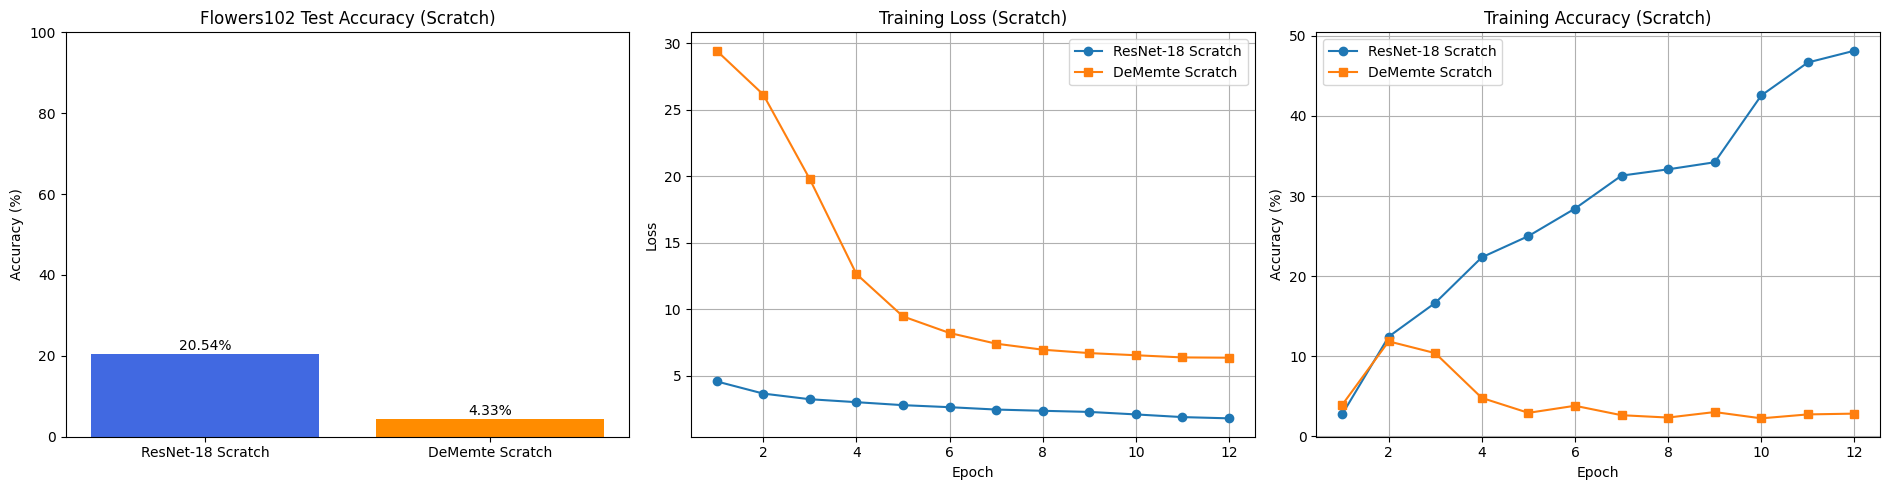

In [4]:
def eval_classifier(model, loader, is_dememte=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if is_dememte:
                outputs, _, _, _, _ = model(inputs)
            else:
                outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100.0 * correct / total

def dememte_loss_scratch(logits, labels, x_rec, features, mu, logvar, model, sparsity_weight=0.005):
    task_loss = F.cross_entropy(logits, labels)
    recon_loss = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    vae_loss = recon_loss + kld_loss

    sparsity_loss = 0.0
    for module in model.modules():
        if isinstance(module, LearnedSparseLinear):
            sparsity_loss += module.sparsity_loss()

    return task_loss + 0.05 * vae_loss + sparsity_weight * sparsity_loss

# Modelos desde cero
baseline_flowers_scratch = models.resnet18(weights=None)
num_ftrs = baseline_flowers_scratch.fc.in_features
baseline_flowers_scratch.fc = nn.Linear(num_ftrs, 102)
baseline_flowers_scratch = baseline_flowers_scratch.to(device)

base_model_scratch = models.resnet18(weights=None)
backbone_scratch = torch.nn.Sequential(*list(base_model_scratch.children())[:-1], torch.nn.Flatten())
dememte_flowers_scratch = DeMemte(backbone=backbone_scratch, vae=VAE(512, 512, 128), embedding_dim=512, num_classes=102).to(device)

optimizer_baseline = optim.Adam(baseline_flowers_scratch.parameters(), lr=1e-3)
optimizer_dememte = optim.Adam([
    {'params': dememte_flowers_scratch.backbone.parameters(), 'lr': 1e-4},
    {'params': dememte_flowers_scratch.vae.parameters(), 'lr': 1e-4},
    {'params': dememte_flowers_scratch.classifier.parameters(), 'lr': 1e-3},
    {'params': [dememte_flowers_scratch.signal_gamma, dememte_flowers_scratch.memory_scale], 'lr': 1e-3},
])

epochs = 12
history_baseline = {'loss': [], 'acc': []}
history_dememte = {'loss': [], 'acc': []}

print('[Scratch] Training ResNet-18 on Flowers102...')
for epoch in range(epochs):
    baseline_flowers_scratch.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader_flowers:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_baseline.zero_grad()
        outputs = baseline_flowers_scratch(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_baseline.step()
        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    history_baseline['loss'].append(running_loss / len(trainloader_flowers))
    history_baseline['acc'].append(100.0 * correct / total)
    print(f"Baseline | Epoch {epoch+1}/{epochs} | Loss: {history_baseline['loss'][-1]:.4f} | Acc: {history_baseline['acc'][-1]:.2f}%")

print('\n[Scratch] Training DeMemte on Flowers102...')
for epoch in range(epochs):
    dememte_flowers_scratch.train()
    running_loss, correct, total = 0.0, 0, 0
    temp = max(0.4, 1.0 - 0.05 * epoch)
    for module in dememte_flowers_scratch.modules():
        if isinstance(module, LearnedSparseLinear):
            module.temperature = temp

    for inputs, labels in trainloader_flowers:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_dememte.zero_grad()
        logits, x_rec, mu, logvar, features = dememte_flowers_scratch(inputs)
        loss = dememte_loss_scratch(logits, labels, x_rec, features, mu, logvar, dememte_flowers_scratch)
        loss.backward()
        optimizer_dememte.step()
        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    history_dememte['loss'].append(running_loss / len(trainloader_flowers))
    history_dememte['acc'].append(100.0 * correct / total)
    print(f"DeMemte  | Epoch {epoch+1}/{epochs} | Loss: {history_dememte['loss'][-1]:.4f} | Acc: {history_dememte['acc'][-1]:.2f}%")

acc_baseline = eval_classifier(baseline_flowers_scratch, testloader_flowers, is_dememte=False)
acc_dememte = eval_classifier(dememte_flowers_scratch, testloader_flowers, is_dememte=True)

print('\n[Scratch] Flowers102 Test Accuracy')
print(f'ResNet-18 Scratch: {acc_baseline:.2f}%')
print(f'DeMemte Scratch:   {acc_dememte:.2f}%')

fig, axs = plt.subplots(1, 3, figsize=(19, 5))
labels = ['ResNet-18 Scratch', 'DeMemte Scratch']
vals = [acc_baseline, acc_dememte]
axs[0].bar(labels, vals, color=['royalblue', 'darkorange'])
axs[0].set_title('Flowers102 Test Accuracy (Scratch)')
axs[0].set_ylabel('Accuracy (%)')
axs[0].set_ylim(0, 100)
for i, v in enumerate(vals):
    axs[0].text(i, v + 1, f'{v:.2f}%', ha='center')

epochs_axis = range(1, epochs + 1)
axs[1].plot(epochs_axis, history_baseline['loss'], marker='o', label='ResNet-18 Scratch')
axs[1].plot(epochs_axis, history_dememte['loss'], marker='s', label='DeMemte Scratch')
axs[1].set_title('Training Loss (Scratch)')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(epochs_axis, history_baseline['acc'], marker='o', label='ResNet-18 Scratch')
axs[2].plot(epochs_axis, history_dememte['acc'], marker='s', label='DeMemte Scratch')
axs[2].set_title('Training Accuracy (Scratch)')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Accuracy (%)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()